# 2D Ornstein-Uhlenbeck processes


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

def simulate_ou_process_2d(
    theta,      # Mean reversion strength
    sigma,      # Diffusion coefficient
    mu,         # Long-term mean (array [mu_x, mu_y])
    X0,         # Initial position (array [x0, y0] or list of arrays)
    T,          # Total time
    dt,         # Time step
    num_paths   # Number of trajectories to simulate
):
    """
    Simulates 2D Ornstein-Uhlenbeck processes using the Euler-Maruyama method.
    Equation: dX_t = theta * (mu - X_t) * dt + sigma * dW_t
    """
    N = int(T / dt)
    t = np.linspace(0, T, N)
    
    # Initialize arrays to store paths: dimensions (steps, paths, 2)
    # The last dimension holds x and y coordinates
    paths = np.zeros((N, num_paths, 2))
    
    # Set initial conditions
    # If X0 is provided as a single point, broadcast it. 
    # Otherwise assume X0 is (num_paths, 2)
    if isinstance(X0, list) or X0.ndim == 1:
        paths[0, :, :] = X0
    else:
        paths[0, :, :] = X0
        
    # Euler-Maruyama Integration
    # X_{t+1} = X_t + theta * (mu - X_t) * dt + sigma * sqrt(dt) * Z
    sqrt_dt = np.sqrt(dt)
    
    for i in range(N - 1):
        # Current state X_t
        X_t = paths[i, :, :]
        
        # Generate Brownian increments (Z ~ N(0, 1))
        # Shape: (num_paths, 2)
        Z = np.random.normal(0, 1, size=(num_paths, 2))
        
        # Calculate drift: theta * (mu - X_t)
        drift = theta * (mu - X_t) * dt
        
        # Calculate diffusion: sigma * dW_t
        diffusion = sigma * sqrt_dt * Z
        
        # Update
        paths[i + 1, :, :] = X_t + drift + diffusion
        
    return t, paths

def plot_simulation(t, paths, mu, title, subplot_ax):
    """
    Helper function to plot 2D trajectories on a given subplot axis.
    """
    num_paths = paths.shape[1]
    
    # Plot each path
    for p in range(num_paths):
        subplot_ax.plot(paths[:, p, 0], paths[:, p, 1], lw=0.8, alpha=0.6)
        
    # Plot the Mean (Target)
    subplot_ax.plot(mu[0], mu[1], 'ro', markersize=8, label=r'$\mu$ (Mean)', zorder=10)
    
    # Plot Start points (roughly)
    subplot_ax.plot(paths[0, :, 0], paths[0, :, 1], 'k.', markersize=2, alpha=0.5, label='Start')

    subplot_ax.set_title(title)
    subplot_ax.set_xlabel('X')
    subplot_ax.set_ylabel('Y')
    subplot_ax.grid(True, alpha=0.3)
    subplot_ax.legend()
    subplot_ax.axis('equal')


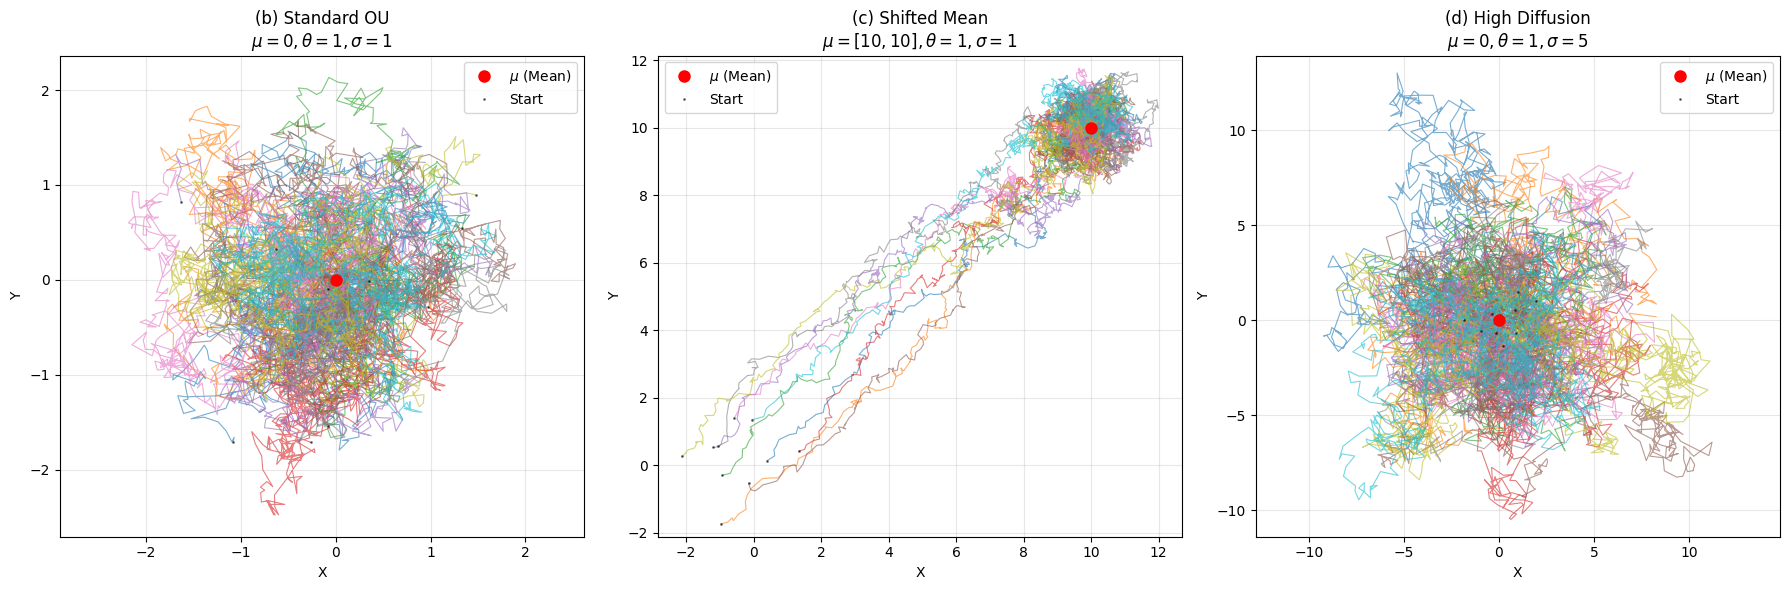

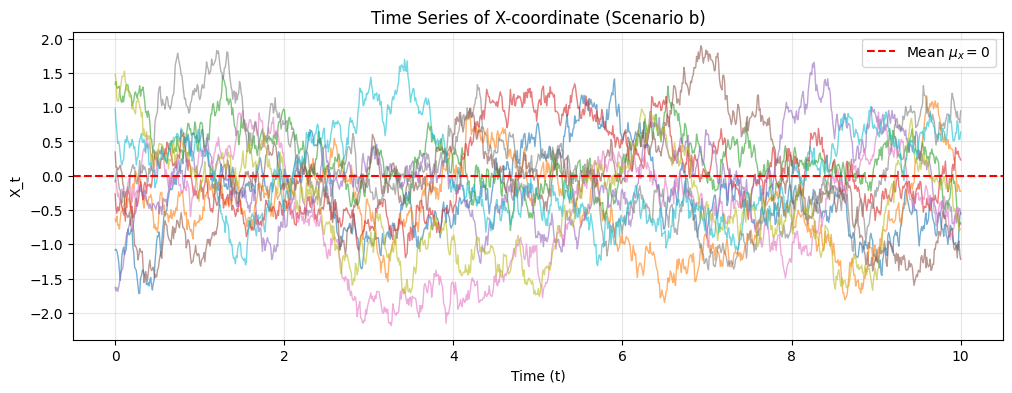

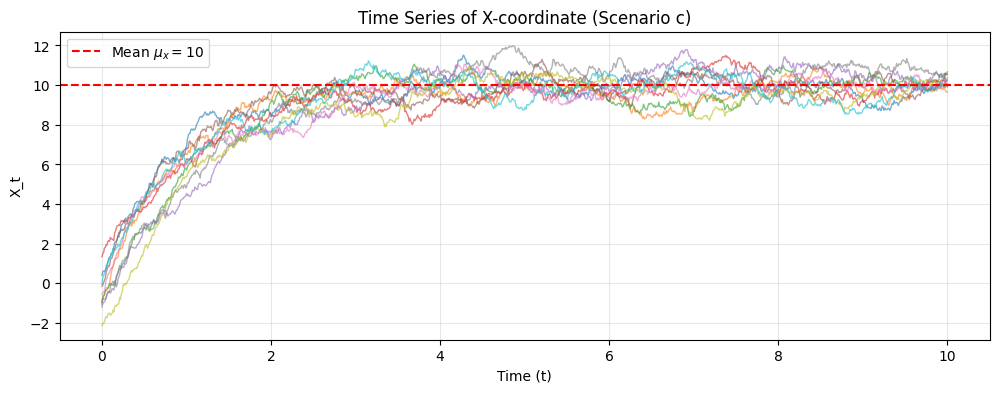

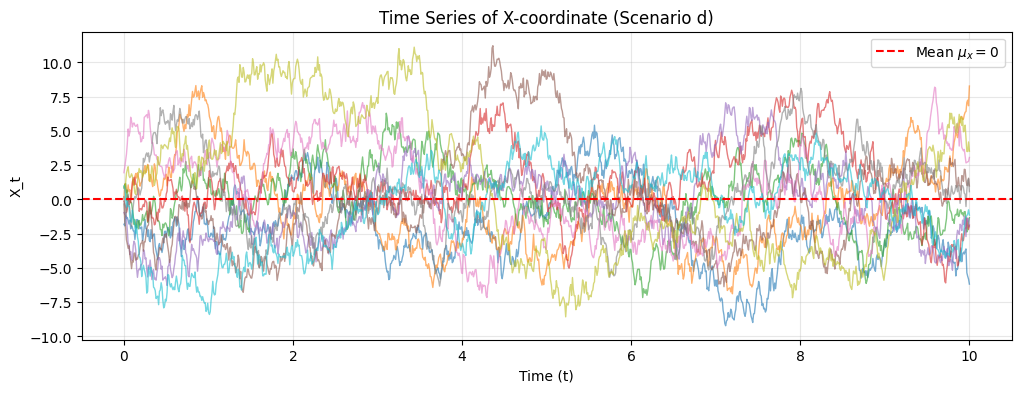

In [13]:

# --- Simulation Parameters ---
T = 10.0
dt = 0.01
num_paths = 10

# --- Scenario (b): Standard OU Process ---
# "X0 ~ N(0, I), theta > 0, trajectories tethered to origin"
theta_b = 1.0
sigma_b = 1.0
mu_b = np.array([0.0, 0.0])
# Generate random initial starts around 0
X0_b = np.random.normal(0, 1, size=(num_paths, 2))

t_b, paths_b = simulate_ou_process_2d(theta_b, sigma_b, mu_b, X0_b, T, dt, num_paths)


# --- Scenario (c): Shifted Mean ---
# "mu = [10, 10]^T. Trajectories start around mu."
theta_c = 1.0
sigma_c = 1.0
mu_c = np.array([10.0, 10.0])
# Start particles around the new mean (10, 10)
X0_c = np.random.normal(0, 1, size=(num_paths, 2))

t_c, paths_c = simulate_ou_process_2d(theta_c, sigma_c, mu_c, X0_c, T, dt, num_paths)


# --- Scenario (d): High Diffusion ---
# "sigma is very high. Jagged trajectories."
theta_d = 1.0
sigma_d = 5.0  # High diffusion
mu_d = np.array([0.0, 0.0])
X0_d = np.random.normal(0, 1, size=(num_paths, 2))

t_d, paths_d = simulate_ou_process_2d(theta_d, sigma_d, mu_d, X0_d, T, dt, num_paths)


# --- Plotting All Scenarios ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_simulation(t_b, paths_b, mu_b, 
                "(b) Standard OU\n" + r"$\mu=0, \theta=1, \sigma=1$", 
                axes[0])

plot_simulation(t_c, paths_c, mu_c, 
                "(c) Shifted Mean\n" + r"$\mu=[10,10], \theta=1, \sigma=1$", 
                axes[1])

plot_simulation(t_d, paths_d, mu_d, 
                "(d) High Diffusion\n" + r"$\mu=0, \theta=1, \sigma=5$", 
                axes[2])

plt.tight_layout()
plt.show()

# --- Optional: Visualize X-coordinate over time for Scenario (b) to show Mean Reversion ---
plt.figure(figsize=(12, 4))
for p in range(num_paths):
    plt.plot(t_b, paths_b[:, p, 0], alpha=0.6, lw=1)
plt.axhline(0, color='r', linestyle='--', label=r'Mean $\mu_x=0$')
plt.title("Time Series of X-coordinate (Scenario b)")
plt.xlabel("Time (t)")
plt.ylabel("X_t")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Optional: Visualize X-coordinate over time for Scenario (c) to show Mean Reversion ---
plt.figure(figsize=(12, 4))
for p in range(num_paths):
    plt.plot(t_c, paths_c[:, p, 0], alpha=0.6, lw=1)
plt.axhline(10, color='r', linestyle='--', label=r'Mean $\mu_x=10$')
plt.title("Time Series of X-coordinate (Scenario c)")
plt.xlabel("Time (t)")
plt.ylabel("X_t")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# --- Optional: Visualize X-coordinate over time for Scenario (d) to show Mean Reversion ---
plt.figure(figsize=(12, 4))
for p in range(num_paths):
    plt.plot(t_d, paths_d[:, p, 0], alpha=0.6, lw=1)
plt.axhline(0, color='r', linestyle='--', label=r'Mean $\mu_x=0$')
plt.title("Time Series of X-coordinate (Scenario d)")
plt.xlabel("Time (t)")
plt.ylabel("X_t")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()